In [1]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Define simulation parameters
num_hours = 8760  # One year of hourly data
start_date = "2024-01-01 00:00:00"

# Generate timestamps
timestamps = pd.date_range(start=start_date, periods=num_hours, freq='h')

# Simulate sensor data
flow_rate = np.random.uniform(50, 500, num_hours)  # Water flow rate (liters per second)
pressure = np.random.uniform(20, 100, num_hours)  # Pipe pressure (PSI)
water_quality = np.random.uniform(0.8, 1.0, num_hours)  # Water quality index (0-1 scale)

# Simulate consumer demand with daily patterns
hourly_demand_pattern = np.sin(np.linspace(0, 2 * np.pi, 24)) * 50 + 150  # Base pattern
consumer_demand = np.tile(hourly_demand_pattern, num_hours // 24) + np.random.normal(0, 10, num_hours)

# Simulate external factors
temperature = np.random.uniform(10, 40, num_hours)  # Temperature (°C)
rainfall = np.random.choice([0, 0, 0, 0.5, 1, 2, 5], num_hours, p=[0.6, 0.2, 0.1, 0.05, 0.03, 0.015, 0.005])  # Rainfall (mm)

# Simulate pump & valve status
pump_status = np.random.choice(["ON", "OFF"], num_hours, p=[0.7, 0.3])  # 70% ON, 30% OFF
valve_status = np.random.choice(["OPEN", "CLOSED"], num_hours, p=[0.8, 0.2])  # 80% OPEN

# Simulate leak detection (higher chance during high demand & low pressure)
leak_probability = np.where((consumer_demand > 180) & (pressure < 40), 0.1, 0.02)  # Leak more likely with low pressure
leak_detected = (np.random.rand(num_hours) < leak_probability).astype(int)  # Fixed the error

# Simulate reservoir levels (fluctuate based on demand & supply)
reservoir_levels = np.clip(50000 - np.cumsum(consumer_demand) % 50000 + np.random.uniform(-500, 500, num_hours), 10000, 50000)

# Simulate energy consumption based on pump status
energy_consumption = np.where(pump_status == "ON", np.random.uniform(10, 50, num_hours), 0)  # kWh usage only when ON

# Assign water supply zones (districts)
districts = ["North", "South", "East", "West"]
district = np.random.choice(districts, num_hours)

# Create DataFrame
data = pd.DataFrame({
    "Timestamp": timestamps,
    "Hour_of_Day": timestamps.hour,  # Useful for time-based ML models
    "Day_of_Week": timestamps.dayofweek,
    "Flow_Rate_LPS": flow_rate,
    "Pressure_PSI": pressure,
    "Water_Quality_Index": water_quality,
    "Consumer_Demand_Liters": consumer_demand,
    "Temperature_C": temperature,
    "Rainfall_mm": rainfall,
    "Pump_Status": pump_status,
    "Valve_Status": valve_status,
    "Leak_Detected": leak_detected,  # Binary label for ML classification
    "Reservoir_Level_Liters": reservoir_levels,
    "Energy_Consumption_kWh": energy_consumption,
    "District": district
})

# Save to CSV
data.to_csv("optimized_water_supply_data.csv", index=False)

# Display first few rows
print(data.head())

            Timestamp  Hour_of_Day  Day_of_Week  Flow_Rate_LPS  Pressure_PSI  \
0 2024-01-01 00:00:00            0            0     218.543053     21.568843   
1 2024-01-01 01:00:00            1            0     477.821438     73.709441   
2 2024-01-01 02:00:00            2            0     379.397274     61.852652   
3 2024-01-01 03:00:00            3            0     319.396318     91.891114   
4 2024-01-01 04:00:00            4            0     120.208388     33.151415   

   Water_Quality_Index  Consumer_Demand_Liters  Temperature_C  Rainfall_mm  \
0             0.912241              148.417699      20.911088          0.0   
1             0.919220              169.878527      24.473933          0.0   
2             0.881996              150.483804      35.254785          0.0   
3             0.967697              178.150816      35.600638          0.0   
4             0.837035              199.954231      35.375648          0.0   

  Pump_Status Valve_Status  Leak_Detected  Reservo

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Load data
data = pd.read_csv("optimized_water_supply_data.csv")

# Feature Engineering
data['Pressure_Demand_Ratio'] = data['Pressure_PSI'] / data['Consumer_Demand_Liters']
data['Hourly_Demand_Deviation'] = data['Consumer_Demand_Liters'] - data.groupby('Hour_of_Day')['Consumer_Demand_Liters'].transform('mean')

# Define features and target
X = data[['Flow_Rate_LPS', 'Pressure_PSI', 'Consumer_Demand_Liters', 
          'Temperature_C', 'Rainfall_mm', 'Hour_of_Day', 'Pressure_Demand_Ratio', 
          'Hourly_Demand_Deviation', 'District', 'Pump_Status']]
y = data['Leak_Detected']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Preprocessing
numeric_features = ['Flow_Rate_LPS', 'Pressure_PSI', 'Consumer_Demand_Liters', 
                   'Temperature_C', 'Rainfall_mm', 'Pressure_Demand_Ratio', 
                   'Hourly_Demand_Deviation']
categorical_features = ['District', 'Pump_Status']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

In [3]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    "XGBoost": XGBClassifier(scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train)),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(class_weight='balanced', probability=True)
}

# Cross-validation and evaluation
results = {}
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1')
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    results[name] = {
        "CV F1-Score (Mean)": np.mean(cv_scores),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test F1-Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, pipeline.predict_proba(X_test)[:, 1])
    }

# Compare models
results_df = pd.DataFrame(results).T.sort_values(by="Test F1-Score", ascending=False)
print(results_df)

                     CV F1-Score (Mean)  Test Accuracy  Test F1-Score  \
Logistic Regression            0.065403       0.662100       0.066246   
SVM                            0.059476       0.707192       0.055249   
Gradient Boosting              0.000000       0.970320       0.037037   
Random Forest                  0.000000       0.974886       0.000000   
XGBoost                        0.009091       0.967466       0.000000   

                      ROC AUC  
Logistic Regression  0.590749  
SVM                  0.558096  
Gradient Boosting    0.638666  
Random Forest        0.539413  
XGBoost              0.573584  


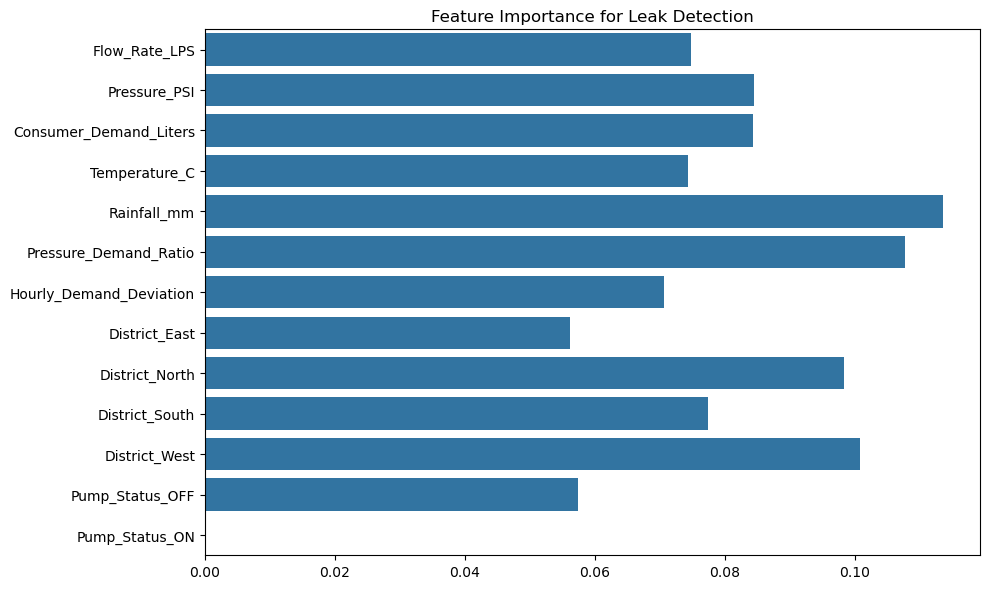

In [4]:
best_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train)))
])
best_model.fit(X_train, y_train)

# Feature Importance
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = best_model.named_steps['classifier'].feature_importances_
cat_encoder = best_model.named_steps['preprocessor'].named_transformers_['cat']
cat_features = cat_encoder.get_feature_names_out(categorical_features)
all_features = numeric_features + list(cat_features)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=all_features)
plt.title("Feature Importance for Leak Detection")
plt.tight_layout()
plt.savefig("feature_importance.png")  # For Streamlit

In [5]:
# 1. DATA PREPROCESSING
# ======================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix
import joblib

# Load data
data = pd.read_csv("optimized_water_supply_data.csv")

# Feature engineering
data['Pressure_Demand_Ratio'] = data['Pressure_PSI'] / (data['Consumer_Demand_Liters'] + 1e-6)
data['Demand_Deviation'] = data['Consumer_Demand_Liters'] - data.groupby('Hour_of_Day')['Consumer_Demand_Liters'].transform('mean')

# Define features and target
X = data[['Flow_Rate_LPS', 'Pressure_PSI', 'Consumer_Demand_Liters', 
          'Temperature_C', 'Rainfall_mm', 'Hour_of_Day', 'Pressure_Demand_Ratio',
          'Demand_Deviation', 'District', 'Pump_Status']]
y = data['Leak_Detected']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Preprocessing
numeric_features = ['Flow_Rate_LPS', 'Pressure_PSI', 'Consumer_Demand_Liters',
                   'Temperature_C', 'Rainfall_mm', 'Pressure_Demand_Ratio',
                   'Demand_Deviation']
categorical_features = ['District', 'Pump_Status']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# ======================
# 2. MODEL TRAINING WITH TUNING
# ======================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

# Define models and hyperparameters
models = {
    "Logistic Regression": {
        "model": LogisticRegression(class_weight='balanced', max_iter=1000),
        "params": {
            'classifier__C': [0.01, 0.1, 1, 10],
            'classifier__solver': ['lbfgs', 'liblinear']
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(class_weight='balanced'),
        "params": {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [None, 10, 20],
            'classifier__min_samples_split': [2, 5]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
                             eval_metric='logloss', use_label_encoder=False),
        "params": {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.01, 0.1],
            'classifier__max_depth': [3, 6]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(),
        "params": {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.01, 0.1],
            'classifier__max_depth': [3, 5]
        }
    },
    "SVM": {
        "model": SVC(class_weight='balanced', probability=True),
        "params": {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['linear', 'rbf']
        }
    }
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

# Hyperparameter tuning and evaluation
for name, config in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', config["model"])
    ])
    
    # Grid search
    grid = GridSearchCV(
        pipeline,
        config["params"],
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    print(f"\nTraining {name}...")
    grid.fit(X_train, y_train)
    
    # Store results
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        "best_params": grid.best_params_,
        "best_score": grid.best_score_,
        "test_f1": f1_score(y_test, y_pred),
        "test_roc_auc": roc_auc_score(y_test, y_proba),
        "model": best_model
    }

# ======================
# 3. MODEL SELECTION
# ======================
results_df = pd.DataFrame(results).T.sort_values(by="test_f1", ascending=False)
print("\nModel Performance Comparison:")
print(results_df[['best_score', 'test_f1', 'test_roc_auc']])

# Select best model
best_model_name = results_df.index[0]
best_model = results[best_model_name]["model"]
print(f"\nBest Model: {best_model_name} with F1-score: {results[best_model_name]['test_f1']:.3f}")

# Save best model
joblib.dump(best_model, "best_leak_detection_model.pkl")


Training Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Training Random Forest...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Training XGBoost...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


c:\Users\Administrator\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:17:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Training Gradient Boosting...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Training SVM...
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Model Performance Comparison:
                    best_score   test_f1 test_roc_auc
SVM                   0.063647   0.07483     0.603524
XGBoost               0.073492  0.070312     0.596345
Logistic Regression    0.05668  0.065217     0.592985
Gradient Boosting     0.017391  0.039216     0.606637
Random Forest         0.011111       0.0     0.555341

Best Model: SVM with F1-score: 0.075


['best_leak_detection_model.pkl']


Evaluating Logistic Regression...

Evaluating Random Forest...


c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Evaluating XGBoost...


c:\Users\Administrator\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:24:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Evaluating SVM...


<Figure size 1200x800 with 0 Axes>

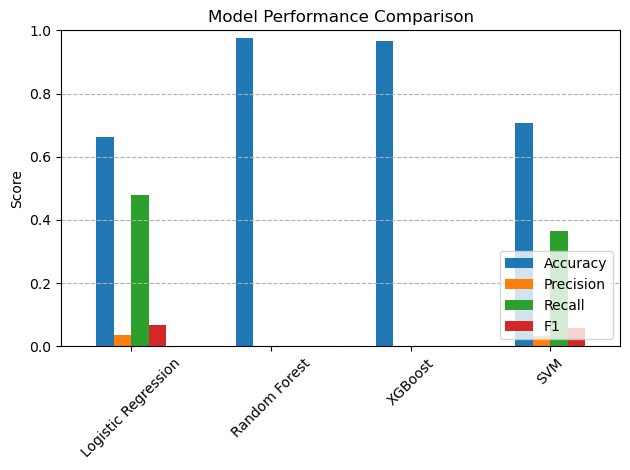

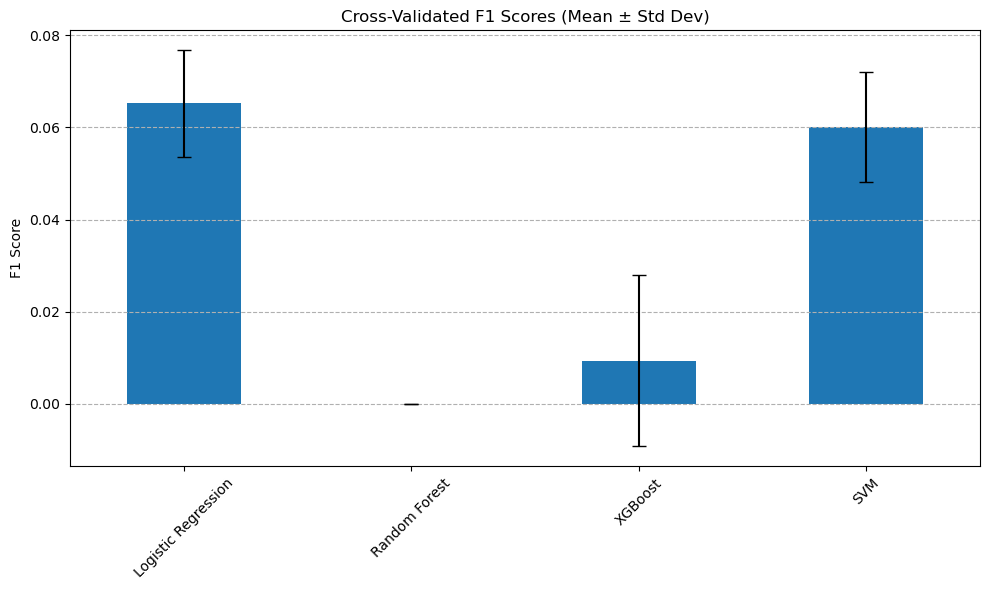

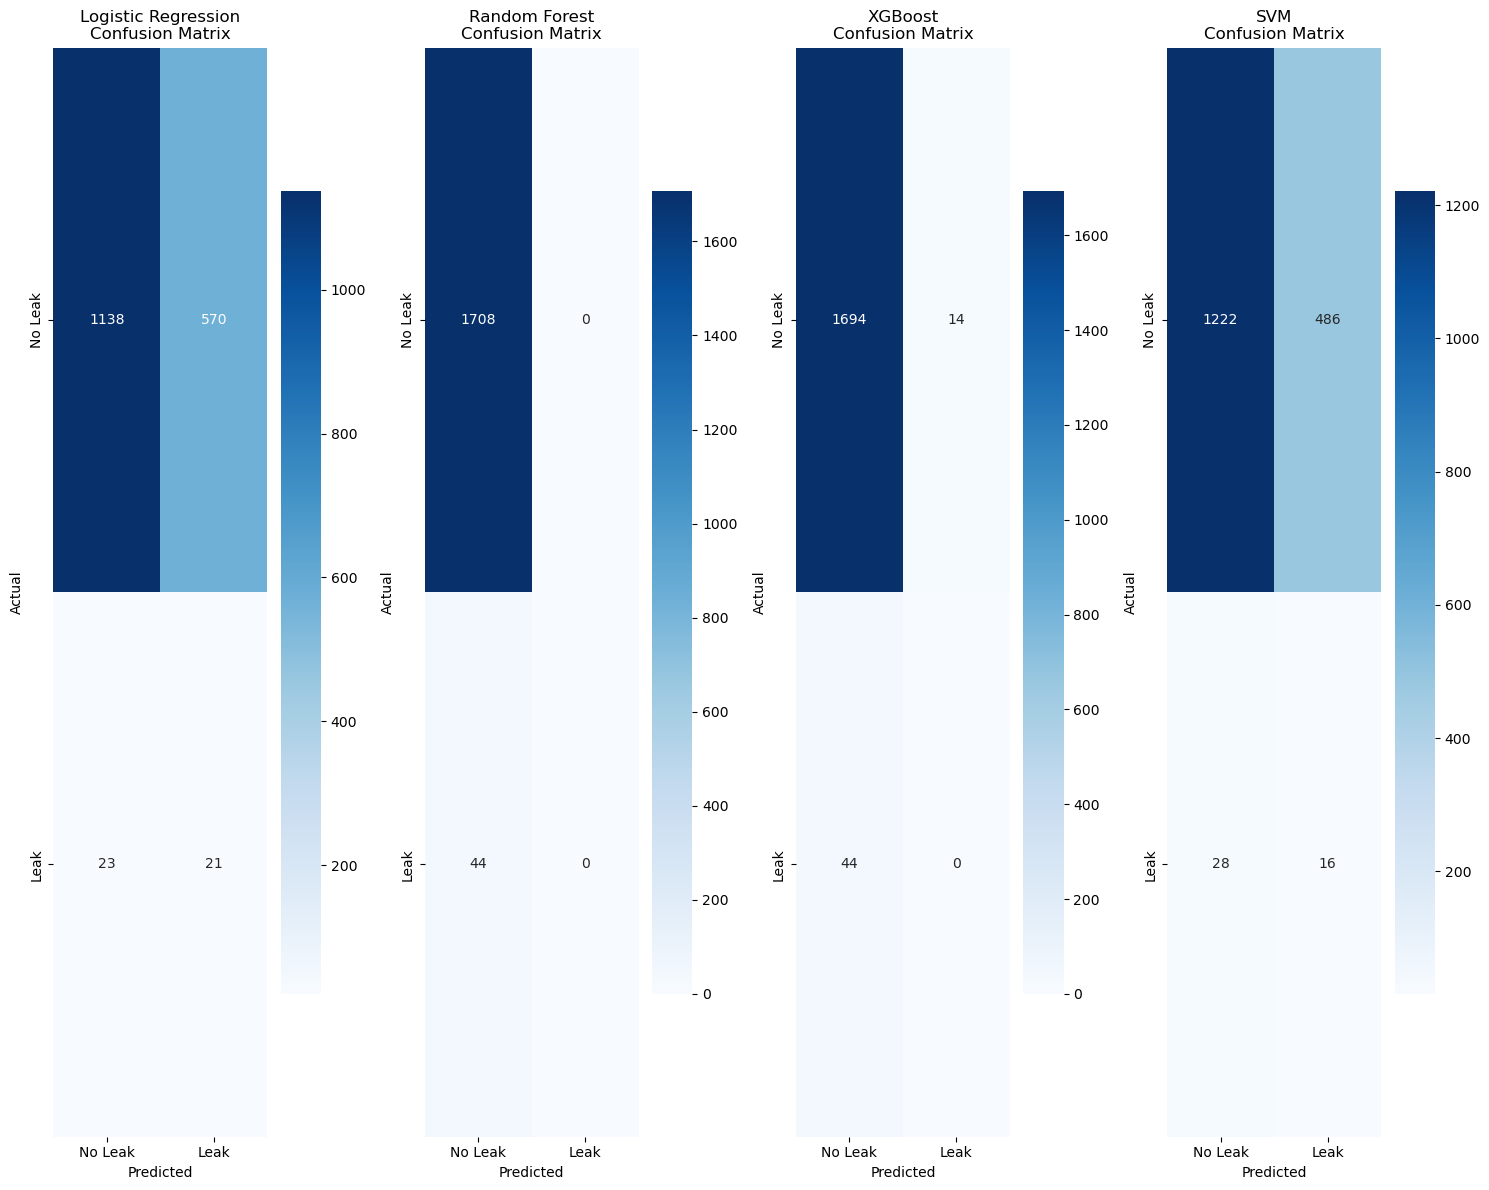

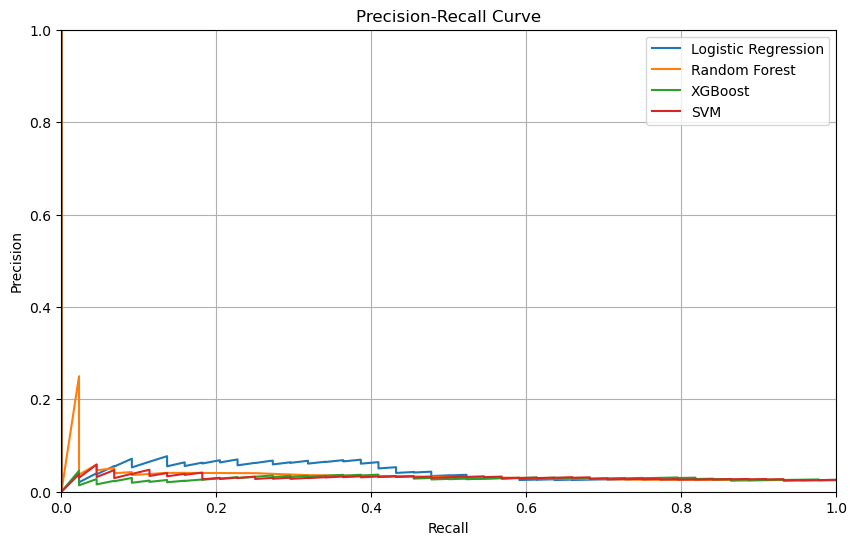

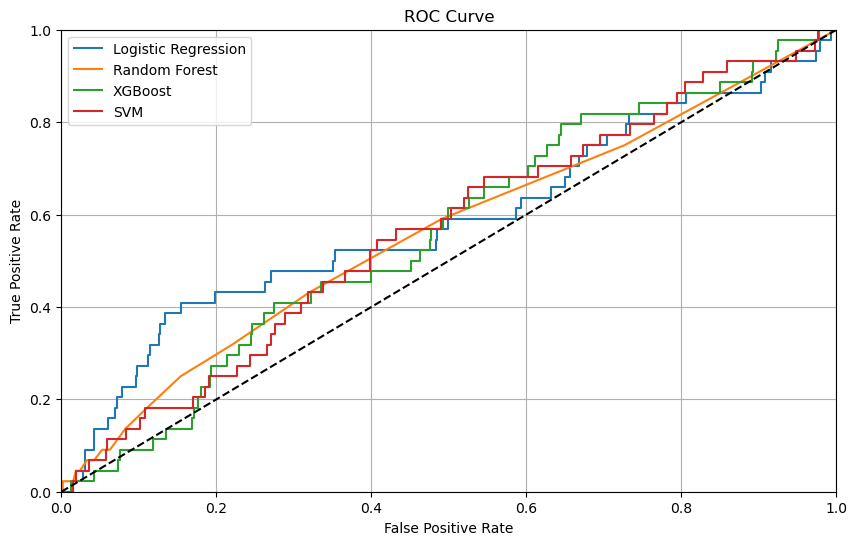


Model Performance Summary:
                     Accuracy  Precision    Recall        F1   ROC AUC  \
Logistic Regression  0.661530   0.035533  0.477273  0.066142  0.586026   
SVM                  0.706621   0.031873  0.363636  0.058608  0.562553   
Random Forest        0.974886   0.000000  0.000000  0.000000  0.560438   
XGBoost              0.966895   0.000000  0.000000  0.000000  0.559972   

                     CV F1 Mean  CV F1 Std  
Logistic Regression    0.065215   0.011583  
SVM                    0.060125   0.011958  
Random Forest          0.000000   0.000000  
XGBoost                0.009302   0.018605  


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix, 
                            precision_recall_curve, roc_curve)
from sklearn.model_selection import cross_validate

def preprocess_data(X):
    """Identify numeric and categorical features"""
    numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ])
    
    return preprocessor

def evaluate_models(X_train, y_train, X_test, y_test, models):
    """
    Evaluate multiple models using cross-validation and test metrics
    
    Args:
        X_train, y_train: Training data
        X_test, y_test: Test data
        models: Dictionary of models to evaluate {name: model}
        
    Returns:
        DataFrame with model metrics
    """
    # Create preprocessor
    preprocessor = preprocess_data(X_train)
    
    metrics = {
        'Accuracy': [],
        'Precision': [],
        'Recall': [],
        'F1': [],
        'ROC AUC': [],
        'CV F1 Mean': [],
        'CV F1 Std': []
    }
    
    confusion_matrices = {}
    pr_curves = {}
    roc_curves = {}
    
    for name, model in models.items():
        print(f"\nEvaluating {name}...")
        
        # Create pipeline with preprocessor
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
        
        # Cross-validation
        cv_results = cross_validate(
            pipeline, X_train, y_train, 
            cv=5, 
            scoring=['f1', 'accuracy', 'precision', 'recall', 'roc_auc'],
            n_jobs=-1
        )
        
        # Train and predict
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        
        # Store metrics
        metrics['Accuracy'].append(accuracy_score(y_test, y_pred))
        metrics['Precision'].append(precision_score(y_test, y_pred))
        metrics['Recall'].append(recall_score(y_test, y_pred))
        metrics['F1'].append(f1_score(y_test, y_pred))
        metrics['ROC AUC'].append(roc_auc_score(y_test, y_proba))
        metrics['CV F1 Mean'].append(cv_results['test_f1'].mean())
        metrics['CV F1 Std'].append(cv_results['test_f1'].std())
        
        # Store visualizations data
        confusion_matrices[name] = confusion_matrix(y_test, y_pred)
        
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        pr_curves[name] = (precision, recall)
        
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_curves[name] = (fpr, tpr)
    
    # Create metrics dataframe
    metrics_df = pd.DataFrame(metrics, index=models.keys())
    
    # Plot metrics
    plot_model_metrics(metrics_df)
    plot_confusion_matrices(confusion_matrices)
    plot_precision_recall_curves(pr_curves)
    plot_roc_curves(roc_curves)
    
    return metrics_df

# [Keep all the plotting functions the same as in your original code]

# Example usage:
if __name__ == "__main__":
    # Load your data
    data = pd.read_csv("optimized_water_supply_data.csv")
    
    # Feature engineering
    data['Pressure_Demand_Ratio'] = data['Pressure_PSI'] / (data['Consumer_Demand_Liters'] + 1e-6)
    data['Demand_Deviation'] = data['Consumer_Demand_Liters'] - data.groupby('Hour_of_Day')['Consumer_Demand_Liters'].transform('mean')
    
    # Define features and target
    X = data[['Flow_Rate_LPS', 'Pressure_PSI', 'Consumer_Demand_Liters', 
              'Temperature_C', 'Rainfall_mm', 'Hour_of_Day', 'Pressure_Demand_Ratio',
              'Demand_Deviation', 'District', 'Pump_Status']]
    y = data['Leak_Detected']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Define models
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from xgboost import XGBClassifier
    from sklearn.svm import SVC
    
    models = {
        "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000),
        "Random Forest": RandomForestClassifier(class_weight='balanced'),
        "XGBoost": XGBClassifier(scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
                               eval_metric='logloss', use_label_encoder=False),
        "SVM": SVC(class_weight='balanced', probability=True)
    }
    
    # Evaluate models
    metrics_df = evaluate_models(X_train, y_train, X_test, y_test, models)
    
    # Display metrics sorted by F1 score
    print("\nModel Performance Summary:")
    print(metrics_df.sort_values('F1', ascending=False))
    
    # Save metrics to CSV
    metrics_df.to_csv("model_metrics.csv")

In [12]:
# 1. MODEL TRAINING & SELECTION
# ======================
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

# Load data
data = pd.read_csv("optimized_water_supply_data.csv")

# Feature engineering
data['Pressure_Demand_Ratio'] = data['Pressure_PSI'] / (data['Consumer_Demand_Liters'] + 1e-6)
data['Hourly_Demand_Deviation'] = data['Consumer_Demand_Liters'] - data.groupby('Hour_of_Day')['Consumer_Demand_Liters'].transform('mean')

# Define features and target
X = data[['Flow_Rate_LPS', 'Pressure_PSI', 'Consumer_Demand_Liters', 
          'Temperature_C', 'Rainfall_mm', 'Hour_of_Day', 'Pressure_Demand_Ratio',
          'Hourly_Demand_Deviation', 'District', 'Pump_Status']]
y = data['Leak_Detected']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Preprocessing
numeric_features = ['Flow_Rate_LPS', 'Pressure_PSI', 'Consumer_Demand_Liters',
                   'Temperature_C', 'Rainfall_mm', 'Pressure_Demand_Ratio',
                   'Hourly_Demand_Deviation']
categorical_features = ['District', 'Pump_Status']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Define models
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
                            eval_metric='logloss', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(class_weight='balanced', probability=True, random_state=42)
}

# Train and evaluate models
best_accuracy = 0
best_model = None
best_model_name = ""

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"{name} - Accuracy: {accuracy:.4f}")
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = pipeline
        best_model_name = name

print(f"\nBest Model: {best_model_name} with Accuracy: {best_accuracy:.4f}")

# Save the best model
joblib.dump(best_model, "best_leak_detection_model.pkl")
print("Best model saved as 'best_leak_detection_model.pkl'")

Logistic Regression - Accuracy: 0.6621
Random Forest - Accuracy: 0.9749
XGBoost - Accuracy: 0.9675
Gradient Boosting - Accuracy: 0.9703
SVM - Accuracy: 0.7072

Best Model: Random Forest with Accuracy: 0.9749
Best model saved as 'best_leak_detection_model.pkl'


In [14]:
# 1. SAVE THE BEST PERFORMING MODEL (based on accuracy)
import joblib
from sklearn.metrics import classification_report

# Ensure all required features are present in X_test
if 'Hourly_Demand_Deviation' not in X_test.columns:
    print("Calculating missing feature: Hourly_Demand_Deviation")
    X_test['Hourly_Demand_Deviation'] = X_test['Consumer_Demand_Liters'] - data.groupby('Hour_of_Day')['Consumer_Demand_Liters'].transform('mean')

if 'Pressure_Demand_Ratio' not in X_test.columns:
    print("Calculating missing feature: Pressure_Demand_Ratio")
    X_test['Pressure_Demand_Ratio'] = X_test['Pressure_PSI'] / (X_test['Consumer_Demand_Liters'] + 1e-6)

# Verify all required columns are present
required_columns = ['Flow_Rate_LPS', 'Pressure_PSI', 'Consumer_Demand_Liters',
                   'Temperature_C', 'Rainfall_mm', 'Hour_of_Day', 'Pressure_Demand_Ratio',
                   'Hourly_Demand_Deviation', 'District', 'Pump_Status']

missing_cols = set(required_columns) - set(X_test.columns)
if missing_cols:
    raise ValueError(f"Columns are still missing: {missing_cols}")

# Now generate predictions
try:
    y_pred = best_model.predict(X_test[required_columns])  # Ensure correct column order
    print(f"\nClassification Report for {best_model_name}:")
    print(classification_report(y_test, y_pred))
    
    # Save the best model
    model_filename = "best_water_model.pkl"
    joblib.dump(best_model, model_filename)
    print(f"\nSaved best model ({best_model_name}) as {model_filename}")
    
except Exception as e:
    print(f"\nError during prediction: {str(e)}")
    print("\nDebugging info:")
    print(f"X_test columns: {X_test.columns.tolist()}")
    print(f"Required columns: {required_columns}")
    print(f"Model features: {best_model.named_steps['preprocessor'].get_feature_names_out()}")


Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1708
           1       0.00      0.00      0.00        44

    accuracy                           0.97      1752
   macro avg       0.49      0.50      0.49      1752
weighted avg       0.95      0.97      0.96      1752


Saved best model (Random Forest) as best_water_model.pkl


c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        X = X.copy()
        X['Pressure_Demand_Ratio'] = X['Pressure_PSI'] / (X['Consumer_Demand_Liters'] + 1e-6)
        X['Hourly_Demand_Deviation'] = X['Consumer_Demand_Liters'] - X.groupby('Hour_of_Day')['Consumer_Demand_Liters'].transform('mean')
        return X

# Include in your pipeline:
pipeline = Pipeline([
    ('features', FeatureEngineer()),
    ('preprocessor', preprocessor),
    ('classifier', model)
])

In [16]:
# CONTINUATION FROM MODEL SELECTION
# ======================

# 1. SAVE THE BEST MODEL WITH FEATURE ENGINEERING PIPELINE
import joblib
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Custom feature engineering transformer"""
    def fit(self, X, y=None):
        # Calculate mean demand per hour for later use
        if isinstance(X, pd.DataFrame):
            self.hourly_demand_means_ = X.groupby('Hour_of_Day')['Consumer_Demand_Liters'].mean()
        return self
        
    def transform(self, X):
        X = X.copy()
        # Pressure-demand ratio
        X['Pressure_Demand_Ratio'] = X['Pressure_PSI'] / (X['Consumer_Demand_Liters'] + 1e-6)
        
        # Hourly demand deviation
        if hasattr(self, 'hourly_demand_means_'):
            X['Hourly_Demand_Deviation'] = X['Consumer_Demand_Liters'] - \
                                          X['Hour_of_Day'].map(self.hourly_demand_means_)
        else:
            # Fallback if not fitted
            X['Hourly_Demand_Deviation'] = 0
            
        return X

# Recreate the full pipeline with feature engineering
final_pipeline = Pipeline([
    ('features', FeatureEngineer()),
    ('preprocessor', preprocessor),
    ('classifier', best_model.named_steps['classifier'])
])

# Refit the pipeline to store the hourly demand means
final_pipeline.fit(X_train, y_train)

# Save the complete pipeline
model_filename = "best_water_model.pkl"
joblib.dump(final_pipeline, model_filename)
print(f"\nSaved complete pipeline ({best_model_name}) as {model_filename}")


Saved complete pipeline (Random Forest) as best_water_model.pkl
